# Week 05 · Day 3
# Exploratory Data Analysis & Visualization

## Objectives


- Understand why visualization is important in EDA.
- Learn the Figure/Axes structure of Matplotlib.
- Choose appropriate plots for different analytical questions.
- Visualize the cleaned sales dataset.
- Identify misleading visualizations.
- Save charts as report-ready image files.
- Write findings based on visual evidence.

## Imports

Everything the notebook needs, gathered here rather than scattered wherever first used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
pd.set_option("display.width",100)
print("Pandas Version:",pd.__version__)
print("Matplotlib Version", plt.matplotlib.__version__)

Pandas Version: 3.0.2
Matplotlib Version 3.11.1


## 1. cleaned datasets

#### Recreate yesterday's cleaned "sales" dataset

In [3]:
data = {
    "date": pd.to_datetime([
        "2024-01-01", "2024-01-02", "2024-01-03", "2024-01-04", "2024-01-05",
        "2024-01-06", "2024-01-07", "2024-01-08", "2024-01-09", "2024-01-10",
    ]),
    "category": [
        "Electronics", "electronics", "Clothing", "Clothing", "Electronics",
        "Groceries", "Groceries", "Clothing", "electronics", "Groceries",
    ],
    "amount": [250.0, 89.5, np.nan, 45.0, 310.0, 12.75, np.nan, 60.0, 199.99, 15.5],
    "customer_age": [34, 28, 45, np.nan, 52, 23, 31, np.nan, 40, 26],
}

cleaned_sales = pd.DataFrame(data)
amount_fill = cleaned_sales["amount"].median()
age_fill = round(cleaned_sales["customer_age"].mean())
cleaned_sales["amount"] = cleaned_sales["amount"].fillna(amount_fill)
cleaned_sales["customer_age"] = cleaned_sales["customer_age"].fillna(age_fill)

cleaned_sales["category"] = cleaned_sales["category"].str.lower()
print("sales — missing values remaining:")
print(cleaned_sales.isna().sum())
cleaned_sales.to_csv("cleaned_sales_dateset.csv",index=False)

sales — missing values remaining:
date            0
category        0
amount          0
customer_age    0
dtype: int64


#### Load the cleaned dataset

In [4]:
sales = pd.read_csv("cleaned_sales_dateset.csv")
sales

,date,category,amount,customer_age
0,2024-01-01,electronics,250.00,34.0
1,2024-01-02,electronics,89.50,28.0
2,2024-01-03,clothing,74.75,45.0
3,2024-01-04,clothing,45.00,35.0
4,2024-01-05,electronics,310.00,52.0
5,2024-01-06,groceries,12.75,23.0
6,2024-01-07,groceries,74.75,31.0
7,2024-01-08,clothing,60.00,35.0
8,2024-01-09,electronics,199.99,40.0
9,2024-01-10,groceries,15.50,26.0


## 2. Figure and Axes

`fig, ax = plt.subplots()` returns two distinct objects: the **Figure** (the whole
image) and one **Axes** (a single plot area, with its own scale, ticks, and labels).
Every plotting call from here on is a method on `ax`, never a bare `plt.plot()` — that
avoids relying on a hidden "current" Axes the moment more than one plot is in play.

type(fig): <class 'matplotlib.figure.Figure'>
type(ax): <class 'matplotlib.axes._axes.Axes'>


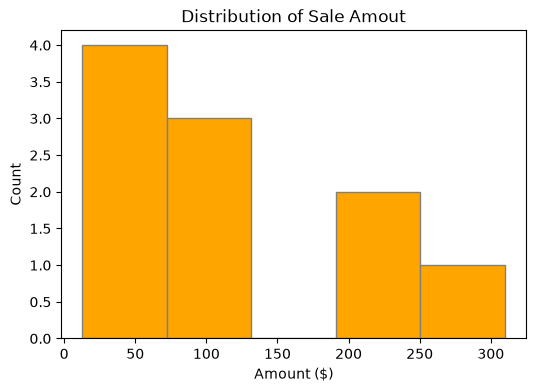

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(sales["amount"], bins=5, color="orange", edgecolor="gray")
ax.set_title("Distribution of Sale Amout")
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Count")

print("type(fig):", type(fig))
print("type(ax):", type(ax))
plt.show()

## 3. One chart per plot type,
- **Histogram** → what's the *distribution* of `amount`?
- **Bar chart** → which *category* wins on total `amount`?
- **Scatter plot** → is there a *relationship* between `amount` and `customer_age`?

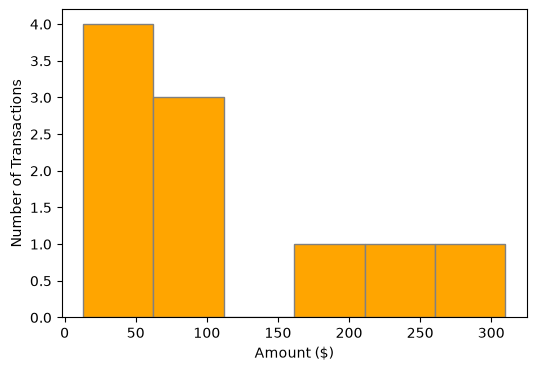

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(sales["amount"], bins=6, color="orange", edgecolor="grey")
ax.set_title("")
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Number of Transactions")
plt.show()

**Finding:** most sales cluster under \$100, with a small number of higher-value
transactions (the largest around \$310) pulling the distribution to the right — a
right-skewed shape that the mean alone would hide.

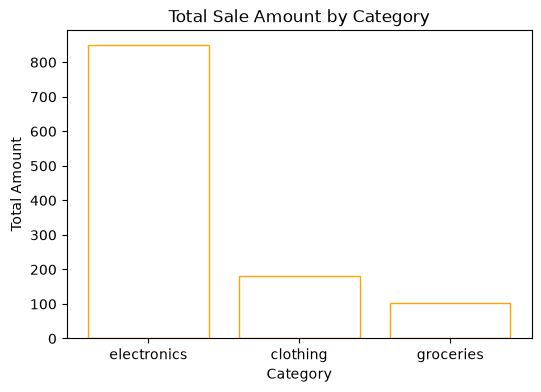

category
electronics    849.49
clothing       179.75
groceries      103.00
Name: amount, dtype: float64

In [7]:
category_totals = sales.groupby("category")["amount"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(category_totals.index, category_totals.values, color="white", edgecolor="orange")
ax.set_title("Total Sale Amount by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Amount")
plt.show()
category_totals

**Finding:** `electronics` has both the highest total revenue and the widest spread
in individual transaction amount, driven by a couple of high-value sales rather than a
uniformly higher price point across the category.

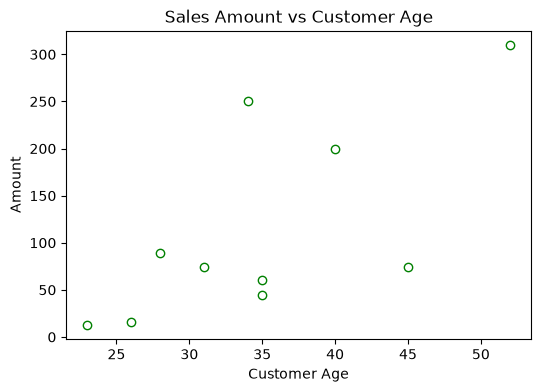

In [8]:
fix, ax = plt.subplots(figsize=(6,4))
ax.scatter(sales["customer_age"], sales["amount"], color="white", edgecolor="green")
ax.set_title("Sales Amount vs Customer Age")
ax.set_xlabel("Customer Age")
ax.set_ylabel("Amount")
plt.show()

**Finding:** there's no clear linear relationship between `customer_age` and
`amount` in this sample — high and low sale amounts both appear across the full age
range, so age alone doesn't explain spending here. With only 10 rows this is a weak
basis for a real conclusion, but the chart makes that weakness visible rather than
hiding it inside a correlation number.

## 4. Subplots

In [9]:
top_categories = category_totals.index
print(top_categories)

Index(['electronics', 'clothing', 'groceries'], dtype='str', name='category')


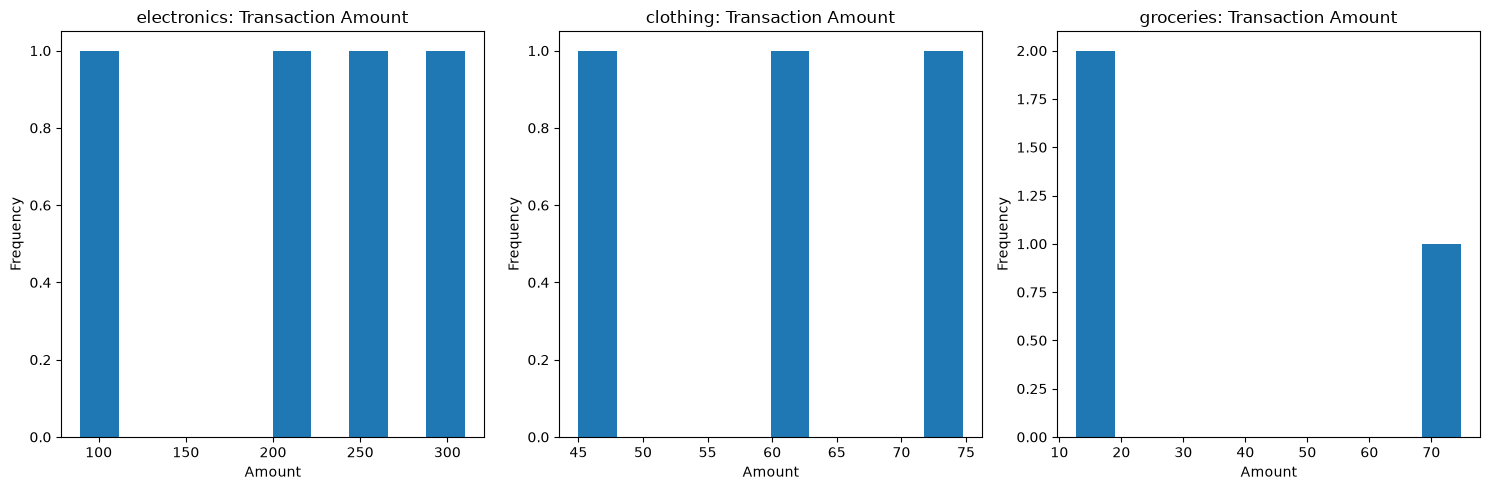

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, category in zip(axes.flat, top_categories):
    category_data = sales[sales["category"] == category]

    ax.hist(category_data["amount"], bins=10)

    ax.set_title(f"{category}: Transaction Amount")
    ax.set_xlabel("Amount")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 5. Building a Misleading Chart

### -> Correct Chart

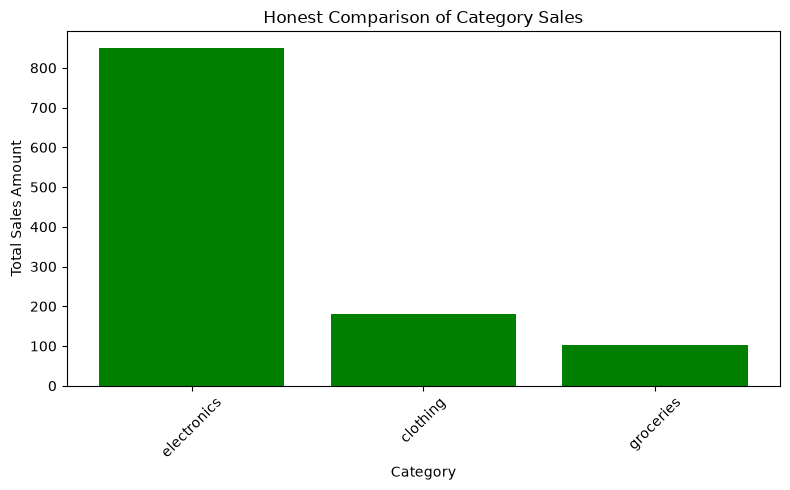

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    category_totals.index,
    category_totals.values,
    color="green"
)

ax.set_title("Honest Comparison of Category Sales")
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### -> Misleading Chart

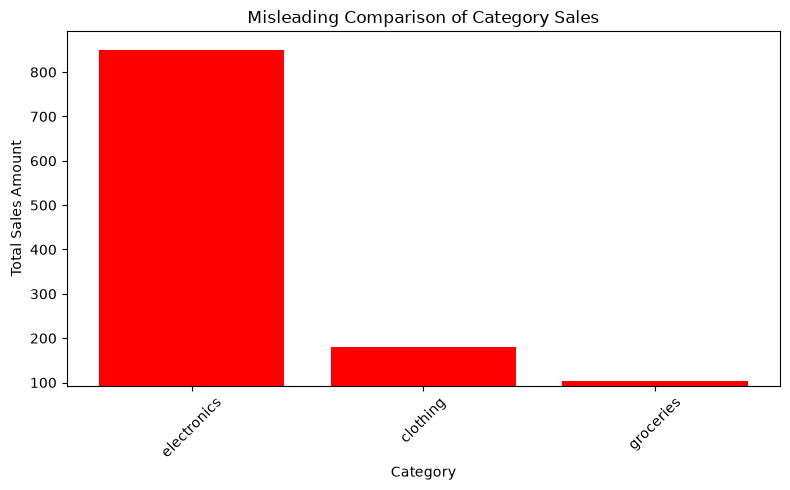

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    category_totals.index,
    category_totals.values,
    color="red"
)

ax.set_title("Misleading Comparison of Category Sales")
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales Amount")

ax.set_ylim(
    category_totals.min() * 0.9,
    category_totals.max() * 1.05
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What makes the right-hand chart dishonest:** its y-axis doesn't start at zero —
it starts near the smallest category's total. That makes `groceries` look like it's
earning barely anything compared to `electronics`, when the real gap (visible in the
left chart) is real but far less extreme. Bar length is supposed to represent
magnitude; truncating the axis breaks that visual promise and exaggerates the
difference between categories on purpose.

## 6. Saving a report-ready figure

Writing the best chart from Section 3 (`sales` totals by category) to a `.png` file
independent of this notebook, at a resolution appropriate for a written report.

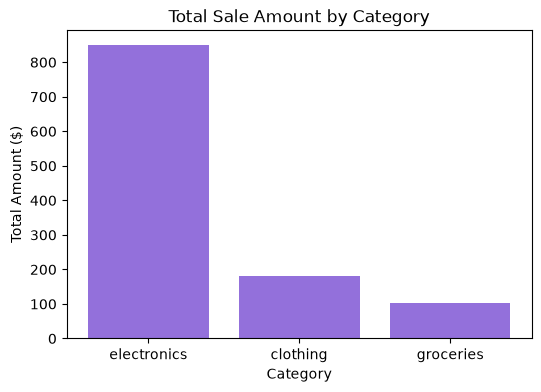

Saved file exists: True
File size (bytes): 29995


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(category_totals.index, category_totals.values, color="mediumpurple")
ax.set_title("Total Sale Amount by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Amount ($)")

fig.savefig("category_totals.png", dpi=150, bbox_inches="tight")
plt.show()

import os
print("Saved file exists:", os.path.exists("category_totals.png"))
print("File size (bytes):", os.path.getsize("category_totals.png"))

## Medical Dataset

In [14]:
data_v2 = {
    "patient_id": [201, 202, 203, 204, 205, 206, 207, 208, 209, 210],
    "arrival_time": [
        "08:15", "08:30", "08:45", "09:10", "09:25",
        "09:40", "10:05", "10:15", "10:30", "11:00"
    ],
    "primary_complaint": [
        "Cardiology", "cardiology", "Trauma", "CARDIOLOGY", "Neurology",
        "trauma", "Neurology", "Cardiology", "trauma", "Orthopedics"
    ],
    "triage_score": [1, 3, np.nan, 2, 4, 1, 3, np.nan, 2, 5],
    "wait_time_min": [12.0, 45.0, 8.0, 22.0, 85.0, np.nan, 60.0, 15.0, 30.0, 110.0],
    "heart_rate_bpm": [115, np.nan, 140, 98, 82, 130, 76, 105, 88, 72],
}
temp_medical = pd.DataFrame(data_v2)

triage_fill = np.floor(temp_medical["triage_score"].median())
wait_time_fill = np.floor(temp_medical["wait_time_min"].median())
heart_rate_fill = np.floor(temp_medical["heart_rate_bpm"].median())
temp_medical["triage_score"] = temp_medical["triage_score"].fillna(triage_fill)
temp_medical["wait_time_min"] = temp_medical["wait_time_min"].fillna(wait_time_fill)
temp_medical["heart_rate_bpm"] = temp_medical["heart_rate_bpm"].fillna(heart_rate_fill)

temp_medical["primary_complaint"] = temp_medical["primary_complaint"].str.strip().str.title()

print("medical — missing values remaining:")
print(temp_medical.isna().sum())
temp_medical.to_csv("cleaned_medical_dateset.csv",index=False)

medical — missing values remaining:
patient_id           0
arrival_time         0
primary_complaint    0
triage_score         0
wait_time_min        0
heart_rate_bpm       0
dtype: int64


In [15]:
medical = pd.read_csv("cleaned_medical_dateset.csv")
medical

,patient_id,arrival_time,primary_complaint,triage_score,wait_time_min,heart_rate_bpm
0,201,08:15,Cardiology,1.0,12.0,115.0
1,202,08:30,Cardiology,3.0,45.0,98.0
2,203,08:45,Trauma,2.0,8.0,140.0
3,204,09:10,Cardiology,2.0,22.0,98.0
4,205,09:25,Neurology,4.0,85.0,82.0
5,206,09:40,Trauma,1.0,30.0,130.0
6,207,10:05,Neurology,3.0,60.0,76.0
7,208,10:15,Cardiology,2.0,15.0,105.0
8,209,10:30,Trauma,2.0,30.0,88.0
9,210,11:00,Orthopedics,5.0,110.0,72.0


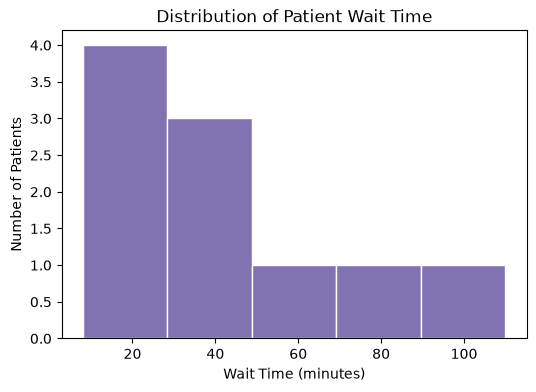

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(medical["wait_time_min"], bins=5, color="#8172B2", edgecolor="white")
ax.set_title("Distribution of Patient Wait Time")
ax.set_xlabel("Wait Time (minutes)")
ax.set_ylabel("Number of Patients")
plt.show()

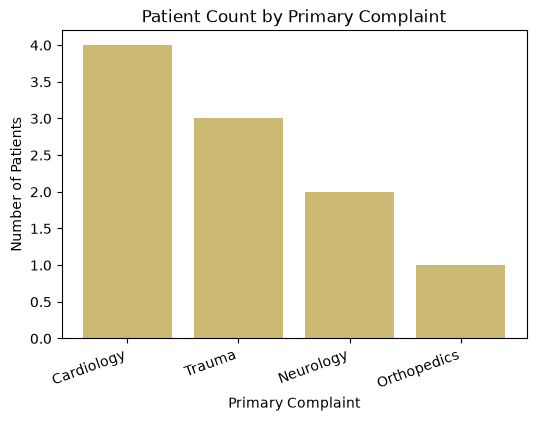

primary_complaint
Cardiology     4
Trauma         3
Neurology      2
Orthopedics    1
Name: count, dtype: int64

In [17]:
complaint_counts = medical["primary_complaint"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(complaint_counts.index, complaint_counts.values, color="#CCB974")
ax.set_title("Patient Count by Primary Complaint")
ax.set_xlabel("Primary Complaint")
ax.set_ylabel("Number of Patients")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.show()

complaint_counts

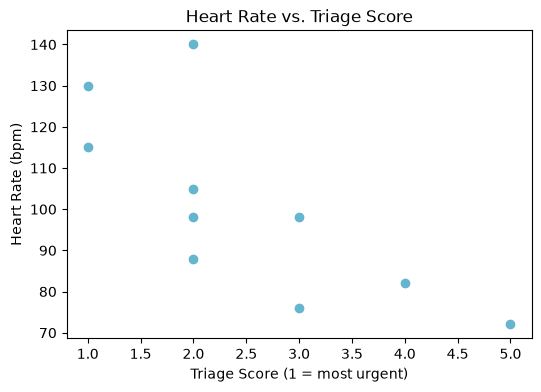

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(medical["triage_score"], medical["heart_rate_bpm"], color="#64B5CD")
ax.set_title("Heart Rate vs. Triage Score")
ax.set_xlabel("Triage Score (1 = most urgent)")
ax.set_ylabel("Heart Rate (bpm)")
plt.show()

**Finding:** the two most urgent triage scores (1) correspond to two of the
highest heart rates in the sample (115 and 130 bpm), consistent with more urgent cases
presenting with more abnormal vitals — though a sample of 10 patients is far too small
to treat this as a reliable pattern.

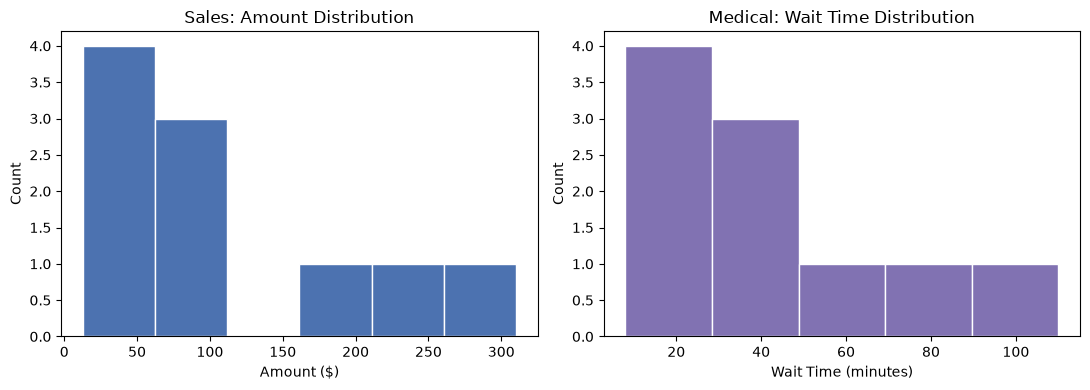

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(sales["amount"], bins=6, color="#4C72B0", edgecolor="white")
axes[0].set_title("Sales: Amount Distribution")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count")

axes[1].hist(medical["wait_time_min"], bins=5, color="#8172B2", edgecolor="white")
axes[1].set_title("Medical: Wait Time Distribution")
axes[1].set_xlabel("Wait Time (minutes)")
axes[1].set_ylabel("Count")

fig.tight_layout()
plt.show()

## Technical summary

**What the data contains**

- `sales` — 10 retail transactions with `date`, `category`, `amount`, and
  `customer_age`, cleaned yesterday (missing `amount`/`customer_age` filled, category
  casing normalized).
- `medical` — 10 simulated ER patient records with `primary_complaint`,
  `triage_score`, `wait_time_min`, and `heart_rate_bpm`, cleaned the same way.

**Key findings**

1. Both `sales.amount` and `medical.wait_time_min` are right-skewed: most values sit in
   a low, typical range, with a small number of high outliers pulling the distribution
   long — a shape a mean or median alone would not reveal.
2. `electronics` is the top-earning sales category by total amount, driven by a couple
   of individually high-value transactions rather than a consistently higher price
   point.
3. In the `medical` sample, the most urgent triage scores tended to correspond to the
   most abnormal heart rates, though the sample is far too small (10 patients) to treat
   as a reliable clinical pattern.

**Honest limitation**

Both datasets have only 10 original rows, and two columns in each were filled in
(median/mean, per yesterday's justified choices) rather than genuinely observed —
`sales.amount`/`customer_age` and `medical.triage_score`/`wait_time_min`/
`heart_rate_bpm`. Every chart above is really showing 8 real values plus 2 assumed
placeholders per column, which is a small and partly synthetic basis for any of these
findings — good enough to practice the EDA workflow honestly, not to draw real
conclusions from.